# CoolRoofs PCA

## Section 1: Setup & Tile Index

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import geopandas as gpd
import numpy as np
import pandas as pd
import os

# TILE INDEX

tile_index = gpd.read_file('/content/drive/MyDrive/Spring 2026/Applied Data Science/ADS Final Project/Data/Orthoimagery Shapefiles/24_b_manhattan_l06_4bd.shp')

def get_tile_name(geom):
    coords = list(geom.exterior.coords)
    x_vals = [c[0] for c in coords]
    y_vals = [c[1] for c in coords]
    x_ll = min(x_vals)
    y_ul = max(y_vals)
    x_part = str(int(x_ll // 1000) % 1000).zfill(3)
    y_part = str(int(y_ul // 1000))
    return x_part + y_part

tile_index["tile_name"] = tile_index["geometry"].apply(get_tile_name)
print(tile_index[["tile_name", "geometry"]].head(5))

  tile_name                                           geometry
0    999260  POLYGON ((1000000 260000, 1002500 260000, 1002...
1    997257  POLYGON ((997500 257500, 1000000 257500, 10000...
2    995254  POLYGON ((995000 255000, 997500 255000, 997500...
3    997254  POLYGON ((997500 255000, 1000000 255000, 10000...
4    992250  POLYGON ((992500 250000, 995000 250000, 995000...


In [3]:
# BOROUGH BOUNDARIES + MANHATTAN TILE LIST

boroughs = gpd.read_file("/content/drive/MyDrive/Spring 2026/Applied Data Science/ADS Final Project/Data/nybb_26a (NYC SHAPE)/nybb.shp")

if tile_index.crs is None:
    tile_index = tile_index.set_crs('EPSG:2263', allow_override=True)
if boroughs.crs is None:
    boroughs = boroughs.set_crs('EPSG:2263', allow_override=True)

boroughs = boroughs.to_crs(tile_index.crs)

manhattan = boroughs[boroughs["BoroName"] == "Manhattan"]

manhattan_tiles = gpd.sjoin(tile_index, manhattan, how="inner", predicate="intersects")
tile_names_needed = manhattan_tiles["tile_name"].tolist()

print(f"Tiles needed for Manhattan: {len(tile_names_needed)}")
print("Sample:", tile_names_needed[:5])

Tiles needed for Manhattan: 158
Sample: ['982222', '002260', '005260', '007260', '002257']


## Section 2: MapPLUTO — Building Data

In [4]:
# MAPPLUTO
# Source: NYC Department of City Planning (v25)

pluto = gpd.read_file("/content/drive/MyDrive/Spring 2026/Applied Data Science/ADS Final Project/Data/nyc_mappluto_25v4_shp (PLUTO)/MapPLUTO.shp")

pluto_mn = pluto[pluto["Borough"] == "MN"].copy()

print(f"Total Manhattan buildings: {len(pluto_mn)}")
print(f"CRS: {pluto_mn.crs}")
print(pluto_mn[["BBL", "YearBuilt", "BldgArea", "NumFloors", "LandUse"]].head())

Total Manhattan buildings: 42061
CRS: EPSG:2263
            BBL  YearBuilt  BldgArea  NumFloors LandUse
0  1.000020e+09       1908    280000        5.0      07
1  1.000010e+09       1900   2542066        3.5      08
2  1.000010e+09          0     63500        3.0      08
3  1.000010e+09          0      8445        0.0      08
4  1.000010e+09       1900    603130        0.0    None


In [5]:
# PLUTO CLEANING
# - BBL converted to integer.
# - YearBuilt = 0 = NaN.
# - Rows missing LandUse, BldgArea, or NumFloors are dropped.
# - Buildings with zero area and invalid geometries are removed.

pluto_mn["BBL"] = pluto_mn["BBL"].astype(np.int64)
pluto_mn["YearBuilt"] = pluto_mn["YearBuilt"].replace(0, np.nan)
pluto_mn = pluto_mn.dropna(subset=["LandUse", "BldgArea", "NumFloors"])
pluto_mn = pluto_mn[pluto_mn["BldgArea"] > 0]
pluto_mn = pluto_mn[pluto_mn.geometry.is_valid]

print("LandUse categories:", pluto_mn["LandUse"].unique())
print(f"Buildings after cleaning: {len(pluto_mn)}")
print(pluto_mn[["BBL", "YearBuilt", "BldgArea", "NumFloors", "LandUse"]].head())

LandUse categories: ['07' '08' '03' '05' '04' '02' '09' '10' '01' '06' '11']
Buildings after cleaning: 40035
          BBL  YearBuilt  BldgArea  NumFloors LandUse
0  1000020001     1908.0    280000        5.0      07
1  1000010010     1900.0   2542066        3.5      08
2  1000010111        NaN     63500        3.0      08
3  1000010112        NaN      8445        0.0      08
5  1000050010     1969.0   1044351       32.0      03


## Section 3: 2024 Orthoimagery — Brightness Extraction

In [6]:
# 2024 IMAGERY FOLDER CHECK

imagery_dir = "/content/drive/MyDrive/Spring 2026/Applied Data Science/ADS Final Project/Data/boro_manhattan_sp24 (IMAGES)"

all_files = os.listdir(imagery_dir)
jp2_files = [f for f in all_files if f.lower().endswith(".jp2")]
actual_files_2024 = [f.replace(".jp2", "") for f in jp2_files]

print(f"Total items in folder: {len(all_files)}")
print(f"JP2 files found: {len(jp2_files)}")
print("Sample filenames:", actual_files_2024[:10])

Total items in folder: 1300
JP2 files found: 258
Sample filenames: ['002240', '970197', '002257', '002250', '005230', '000222', '967197', '005227', '002227', '000217']


In [7]:
import rasterio
from shapely.geometry import box

# SPATIAL TILE MATCHING

manhattan_reproj = boroughs[boroughs["BoroName"] == "Manhattan"].to_crs("EPSG:6539")
manhattan_geom = manhattan_reproj.geometry.union_all()

matched_spatial = []
for tile in actual_files_2024:
    jp2_path = os.path.join(imagery_dir, f"{tile}.jp2")
    try:
        with rasterio.open(jp2_path) as src:
            tile_box = box(src.bounds.left, src.bounds.bottom,
                           src.bounds.right, src.bounds.top)
            if tile_box.intersects(manhattan_geom):
                matched_spatial.append(tile)
    except:
        continue

matched_2024 = matched_spatial
print(f"Tiles covering Manhattan (spatial match): {len(matched_2024)}")

Tiles covering Manhattan (spatial match): 158


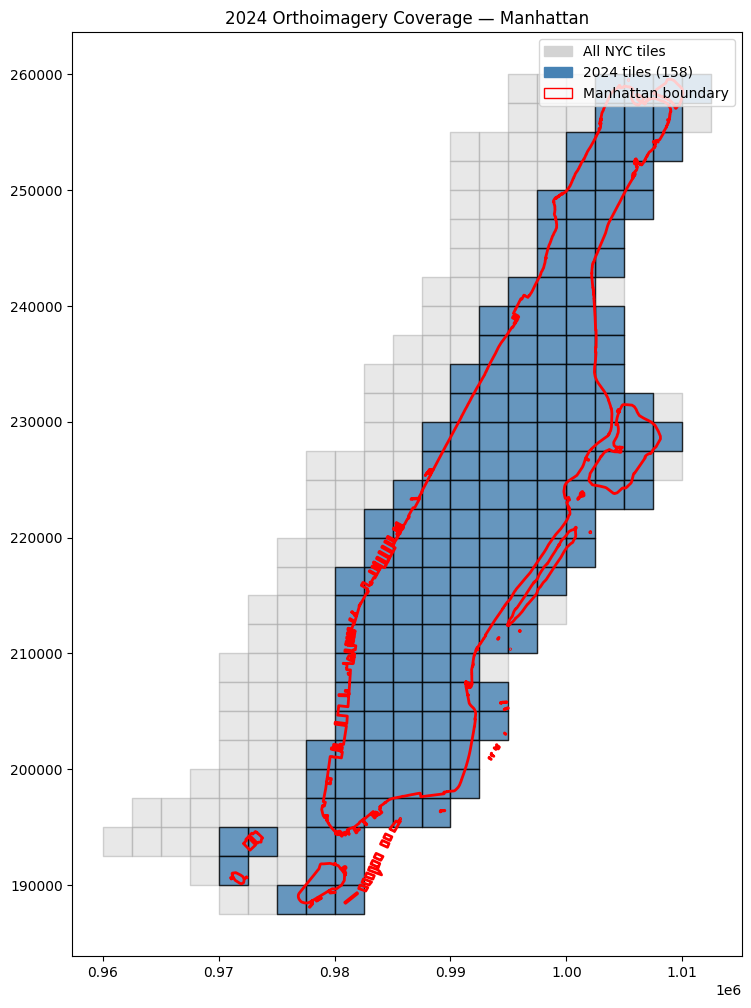

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 2024 IMAGERY COVERAGE MAP

tile_bounds_list = []
for tile in matched_2024:
    jp2_path = os.path.join(imagery_dir, f"{tile}.jp2")
    try:
        with rasterio.open(jp2_path) as src:
            b = src.bounds
            tile_bounds_list.append({
                "tile_name": tile,
                "geometry": box(b.left, b.bottom, b.right, b.top)
            })
    except:
        continue

tiles_2024_gdf = gpd.GeoDataFrame(tile_bounds_list, crs="EPSG:6539")
tile_index_reproj = tile_index.to_crs("EPSG:6539")

fig, ax = plt.subplots(figsize=(10, 12))
tile_index_reproj.plot(ax=ax, color="lightgray", edgecolor="darkgray", alpha=0.5)
tiles_2024_gdf.plot(ax=ax, color="steelblue", edgecolor="black", alpha=0.8)
manhattan_reproj.plot(ax=ax, color="none", edgecolor="red", linewidth=2)

all_patch = mpatches.Patch(color="lightgray", label="All NYC tiles")
have_patch = mpatches.Patch(color="steelblue", label=f"2024 tiles ({len(matched_2024)})")
border_patch = mpatches.Patch(facecolor="none", edgecolor="red", label="Manhattan boundary")
ax.set_title("2024 Orthoimagery Coverage — Manhattan")
ax.legend(handles=[all_patch, have_patch, border_patch])
plt.show()

In [9]:
from rasterio.mask import mask
from shapely.geometry import mapping

# SINGLE TILE TEST

test_tile = "997237"
jp2_path = os.path.join(imagery_dir, f"{test_tile}.jp2")
print(f"Testing tile: {test_tile}")

with rasterio.open(jp2_path) as src:
    pluto_reproj = pluto_mn.to_crs(src.crs)
    tile_box = box(src.bounds.left, src.bounds.bottom,
                   src.bounds.right, src.bounds.top)
    buildings_in_tile = pluto_reproj[pluto_reproj.intersects(tile_box)]
    print(f"Buildings in tile: {len(buildings_in_tile)}")

    results = []
    for _, building in buildings_in_tile.head(10).iterrows():
        try:
            geom = [mapping(building.geometry)]
            out_image, _ = mask(src, geom, crop=True, nodata=0)
            valid = out_image[0] > 0
            if valid.sum() == 0:
                continue
            results.append({
                "BBL": building["BBL"],
                "mean_R": float(out_image[0][valid].mean()),
                "mean_G": float(out_image[1][valid].mean()),
                "mean_B": float(out_image[2][valid].mean()),
                "brightness": float(out_image[:3, valid].mean())
            })
        except Exception as e:
            print(f"  Error on BBL {building['BBL']}: {e}")

print(f"\nExtracted {len(results)} buildings")
print(pd.DataFrame(results))

Testing tile: 997237
Buildings in tile: 875

Extracted 10 buildings
          BBL      mean_R      mean_G      mean_B  brightness
0  1019570078  114.613435  112.548407  117.677749  114.946530
1  1019880106  106.652561   97.703786  105.610245  103.322197
2  1019880107  216.350272  213.916033  210.523098  213.596467
3  1020240058  165.581501  164.291881  161.214594  163.695992
4  1020240061  165.588116  159.934202  157.126034  160.882784
5  1020240157  187.271144  184.517662  180.482587  184.090464
6  1020250002  137.676548  137.718022  142.254577  139.216382
7  1020250003  147.447703  146.519465  148.337529  147.434899
8  1020250005   73.371233   77.134190   93.860721   81.455381
9  1020250011  108.927126  112.019189  122.454864  114.467060


In [10]:
# RESUME LOGIC

output_path = "/content/drive/MyDrive/Spring 2026/Applied Data Science/ADS Final Project/Data/brightness_scores.csv"

if os.path.exists(output_path):
    existing = pd.read_csv(output_path)
    already_done_bbls = set(existing["BBL"].tolist())
    all_results = existing.to_dict("records")
    print(f"Resuming — {len(existing)} buildings already extracted")
else:
    already_done_bbls = set()
    all_results = []
    print("Starting fresh extraction")

Resuming — 40035 buildings already extracted


In [11]:
# FULL BRIGHTNESS EXTRACTION LOOP
# Progress saved every 5 tiles.

for i, tile in enumerate(matched_2024):
    jp2_path = os.path.join(imagery_dir, f"{tile}.jp2")

    if not os.path.exists(jp2_path):
        print(f"[{i+1}/{len(matched_2024)}] MISSING FILE: {tile}")
        continue

    try:
        with rasterio.open(jp2_path) as src:
            pluto_reproj = pluto_mn.to_crs(src.crs)
            tile_box = box(src.bounds.left, src.bounds.bottom,
                           src.bounds.right, src.bounds.top)
            buildings_in_tile = pluto_reproj[pluto_reproj.intersects(tile_box)]

            if len(buildings_in_tile) == 0:
                print(f"[{i+1}/{len(matched_2024)}] Tile {tile}: no buildings, skipping")
                continue

            tile_results = []
            for _, building in buildings_in_tile.iterrows():
                try:
                    if building["BBL"] in already_done_bbls:
                        continue
                    geom = [mapping(building.geometry)]
                    out_image, _ = mask(src, geom, crop=True, nodata=0)
                    valid = out_image[0] > 0
                    if valid.sum() == 0:
                        continue
                    tile_results.append({
                        "BBL": building["BBL"],
                        "mean_R": float(out_image[0][valid].mean()),
                        "mean_G": float(out_image[1][valid].mean()),
                        "mean_B": float(out_image[2][valid].mean()),
                        "brightness": float(out_image[:3, valid].mean())
                    })
                except Exception:
                    continue

            all_results.extend(tile_results)
            already_done_bbls.update([r["BBL"] for r in tile_results])
            print(f"[{i+1}/{len(matched_2024)}] Tile {tile}: "
                  f"{len(tile_results)} buildings (total: {len(all_results)})")

    except Exception as e:
        print(f"[{i+1}/{len(matched_2024)}] ERROR on tile {tile}: {e}")
        continue

    if (i + 1) % 5 == 0:
        pd.DataFrame(all_results).to_csv(output_path, index=False)
        print(f"  -- Progress saved ({len(all_results)} buildings) --")

brightness_df = pd.DataFrame(all_results)
brightness_df.to_csv(output_path, index=False)
print(f"\nDone! Total buildings extracted: {len(brightness_df)}")
print(brightness_df["brightness"].describe())

[1/158] Tile 002257: no buildings, skipping
[2/158] Tile 002250: 0 buildings (total: 40035)
[3/158] Tile 005230: no buildings, skipping
[4/158] Tile 000222: 0 buildings (total: 40035)
[5/158] Tile 005227: 0 buildings (total: 40035)
  -- Progress saved (40035 buildings) --
[6/158] Tile 002227: 0 buildings (total: 40035)
[7/158] Tile 000217: 0 buildings (total: 40035)
[8/158] Tile 000227: 0 buildings (total: 40035)
[9/158] Tile 005257: 0 buildings (total: 40035)
[10/158] Tile 005250: 0 buildings (total: 40035)
  -- Progress saved (40035 buildings) --
[11/158] Tile 000247: 0 buildings (total: 40035)
[12/158] Tile 005225: 0 buildings (total: 40035)
[13/158] Tile 972192: no buildings, skipping
[14/158] Tile 002222: 0 buildings (total: 40035)
[15/158] Tile 002242: 0 buildings (total: 40035)
  -- Progress saved (40035 buildings) --
[16/158] Tile 000235: 0 buildings (total: 40035)
[17/158] Tile 005255: 0 buildings (total: 40035)
[18/158] Tile 002247: 0 buildings (total: 40035)
[19/158] Tile 00

## Section 4: Feature Engineering (v2)

**Changes**

| Change | Reason |
|--------|--------|
| Drop `mean_brightness` | `brightness = mean(R, G, B)` — 100% redundant. Keeping it gave PC1 a brightness axis that dominated all clusters. |
| Add `bldg_area_log` | Raw `BldgArea` spans 100 → 2.5M sq ft. Without log-transform, large towers dominate the building PCs regardless of standardization. |
| Two separate feature sets | `optical_cols` (R, G, B only) vs `building_cols` (age, size, land use). Mixing them was why similar buildings split by brightness. |

In [12]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

DATA_DIR = "/content/drive/MyDrive/Spring 2026/Applied Data Science/ADS Final Project/Data"

# Load saved brightness scores
brightness_df = pd.read_csv(f"{DATA_DIR}/brightness_scores.csv")

# Join brightness to PLUTO
pluto_features = pluto_mn[["BBL", "YearBuilt", "BldgArea", "NumFloors", "LandUse"]].copy()
df = pluto_features.merge(brightness_df, on="BBL", how="inner")
print(f"Buildings after join: {len(df)}")

# Log-transform BldgArea to compress right skew
df["bldg_area_log"] = np.log1p(df["BldgArea"])

# One-hot encode LandUse
df_encoded = pd.get_dummies(df, columns=["LandUse"], prefix="LU")

# OPTICAL FEATURES: roof color only
optical_cols = ["mean_R", "mean_G", "mean_B"]

# BUILDING FEATURES: structure only
building_cols = ["YearBuilt", "bldg_area_log", "NumFloors"] + \
                [c for c in df_encoded.columns if c.startswith("LU_")]

# Drop any rows with NaN in used columns
all_cols = optical_cols + building_cols
df_clean = df_encoded[["BBL"] + all_cols].dropna().copy()
print(f"Buildings after dropping NaN: {len(df_clean)}")
print(f"\nOptical features: {optical_cols}")
print(f"Building features: {building_cols}")
print(f"\nRaw RGB stats (sanity check):")
print(df_clean[optical_cols].describe().round(1))

Buildings after join: 40035
Buildings after dropping NaN: 39956

Optical features: ['mean_R', 'mean_G', 'mean_B']
Building features: ['YearBuilt', 'bldg_area_log', 'NumFloors', 'LU_01', 'LU_02', 'LU_03', 'LU_04', 'LU_05', 'LU_06', 'LU_07', 'LU_08', 'LU_09', 'LU_10', 'LU_11']

Raw RGB stats (sanity check):
        mean_R   mean_G   mean_B
count  39956.0  39956.0  39956.0
mean     114.9    116.0    123.1
std       39.8     35.2     27.4
min        1.8     14.4     48.2
25%       88.7     90.8    102.2
50%      119.0    118.1    123.0
75%      144.6    142.5    143.7
max      234.2    230.8    223.8


## Section 5A: Optical-Only PCA + Clustering

In [13]:
# Standardize optical features
X_opt = df_clean[optical_cols].values
scaler_opt = StandardScaler()
X_opt_scaled = scaler_opt.fit_transform(X_opt)

# PCA
pca_opt = PCA()
X_opt_pca = pca_opt.fit_transform(X_opt_scaled)

print("--- Optical PCA explained variance ---")
cumvar_opt = np.cumsum(pca_opt.explained_variance_ratio_)
for i, v in enumerate(pca_opt.explained_variance_ratio_):
    print(f"  PC{i+1}: {v:.3f}  (cumulative: {cumvar_opt[i]:.3f})")

# Loadings — which channel drives each PC
loadings_opt = pd.DataFrame(
    pca_opt.components_.T,
    index=optical_cols,
    columns=[f"PC{i+1}" for i in range(3)]
)
print("\nLoadings (how each RGB channel loads onto each PC):")
print(loadings_opt.round(3))
print("\nPC1 high absolute loading on all 3 channels = overall brightness axis")
print("PC2/PC3 = color HUE variation (e.g. reddish vs bluish tones)")

--- Optical PCA explained variance ---
  PC1: 0.991  (cumulative: 0.991)
  PC2: 0.008  (cumulative: 1.000)
  PC3: 0.000  (cumulative: 1.000)

Loadings (how each RGB channel loads onto each PC):
          PC1    PC2    PC3
mean_R  0.576 -0.692 -0.434
mean_G  0.580 -0.028  0.814
mean_B  0.576  0.721 -0.385

PC1 high absolute loading on all 3 channels = overall brightness axis
PC2/PC3 = color HUE variation (e.g. reddish vs bluish tones)


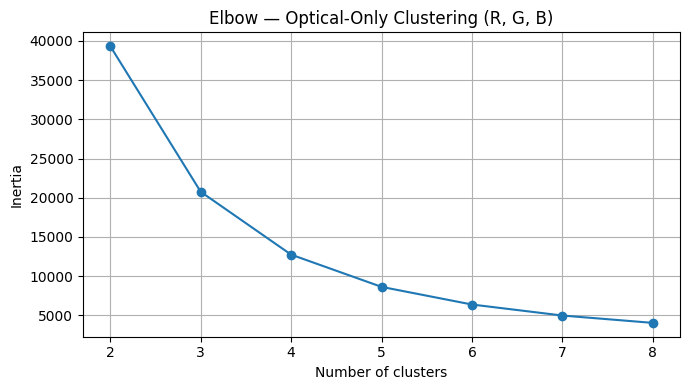

In [14]:
# Elbow method to choose number of optical clusters
inertias_opt = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_opt_scaled)
    inertias_opt.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, inertias_opt, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow — Optical-Only Clustering (R, G, B)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
# Fit optical clusters
n_opt = 3
km_opt = KMeans(n_clusters=n_opt, random_state=42, n_init=10)
df_clean["optical_cluster"] = km_opt.fit_predict(X_opt_scaled)

# Cluster profiles in raw RGB values (easier to interpret than standardized)
opt_profile = df_clean.groupby("optical_cluster")[optical_cols].mean()
opt_profile["brightness"] = (
    opt_profile["mean_R"] + opt_profile["mean_G"] + opt_profile["mean_B"]
) / 3
opt_profile = opt_profile.sort_values("brightness", ascending=False)

print("Optical Cluster Profiles")
print(opt_profile.round(1))

print("\nBuildings per cluster:")
print(df_clean["optical_cluster"].value_counts().sort_index())

Optical Cluster Profiles
                 mean_R  mean_G  mean_B  brightness
optical_cluster                                    
0                 155.9   153.5   153.1       154.2
1                 113.3   113.0   119.2       115.1
2                  61.4    69.5    88.2        73.1

Buildings per cluster:
optical_cluster
0    13770
1    16127
2    10059
Name: count, dtype: int64


## Section 5B: Visualize Optical Clusters in RGB Space

Plot clusters in R vs G, R vs B, and G vs B to confirm they are spatially separated by roof color — not by building size.

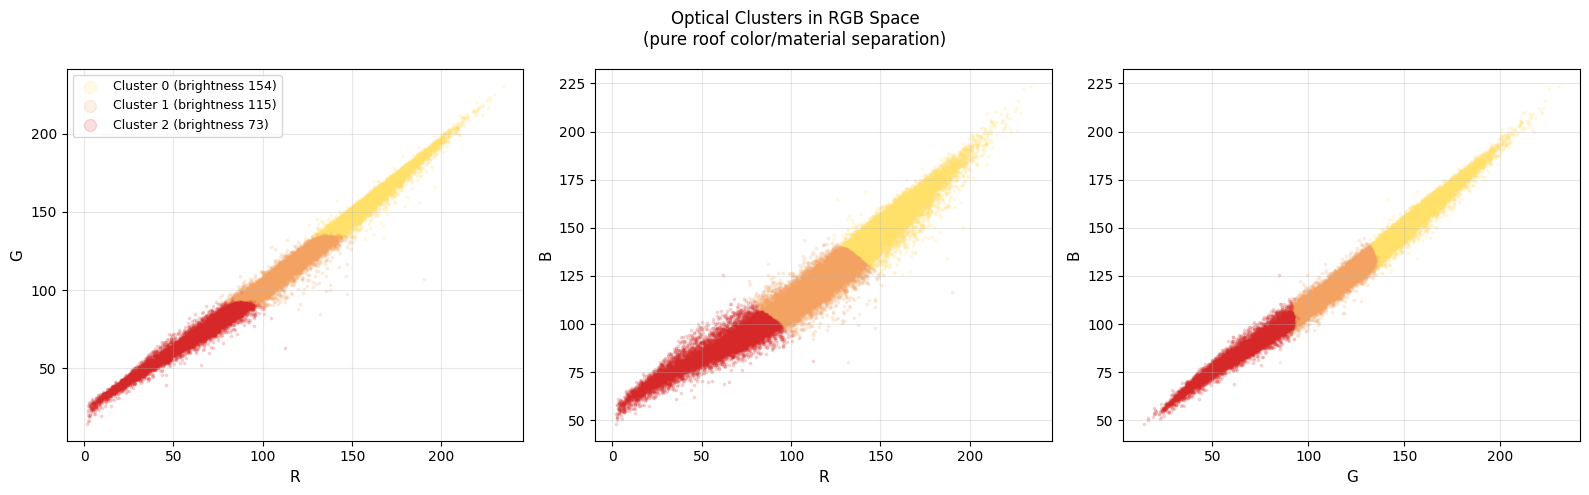

In [16]:
sorted_cluster_ids = opt_profile.index.tolist()  # brightest → darkest
palette = ["#ffe169", "#f4a261", "#d62828", "#4d0000"]  # yellow, orange, red, dark red
color_map = {cid: palette[i % len(palette)] for i, cid in enumerate(sorted_cluster_ids)}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pairs = [("mean_R", "mean_G"), ("mean_R", "mean_B"), ("mean_G", "mean_B")]

for ax, (xc, yc) in zip(axes, pairs):
    for cid in sorted_cluster_ids:
        mask = df_clean["optical_cluster"] == cid
        ax.scatter(
            df_clean.loc[mask, xc],
            df_clean.loc[mask, yc],
            c=color_map[cid],
            alpha=0.15, s=3,
            label=f"Cluster {cid} (brightness {opt_profile.loc[cid, 'brightness']:.0f})"
        )
    ax.set_xlabel(xc.replace("mean_", ""), fontsize=11)
    ax.set_ylabel(yc.replace("mean_", ""), fontsize=11)
    ax.grid(True, alpha=0.3)

axes[0].legend(markerscale=5, fontsize=9, loc="upper left")
fig.suptitle("Optical Clusters in RGB Space\n(pure roof color/material separation)",
             fontsize=12)
plt.tight_layout()
plt.show()

## Section 6: Join Building Data

What kinds of buildings have each roof type?

In [17]:
# Add optical cluster to PLUTO geometry
pca_v2 = df_clean[["BBL", "optical_cluster"]].copy()
pca_v2 = pca_v2.merge(brightness_df[["BBL", "brightness"]], on="BBL", how="left")
pluto_v2 = pluto_mn.merge(pca_v2, on="BBL", how="inner")

print(f"Buildings with optical cluster + geometry: {len(pluto_v2)}")

# Cross-tab: optical cluster × land use type
land_use_labels = {
    "01": "1-Fam Res", "02": "2-3 Fam Res", "03": "Multi-Fam Elevator",
    "04": "Multi-Fam Walkup", "05": "Commercial", "06": "Industrial",
    "07": "Transportation", "08": "Public Facilities", "09": "Open Space",
    "10": "Parking", "11": "Vacant"
}

cross = pd.crosstab(
    pluto_v2["optical_cluster"],
    pluto_v2["LandUse"],
    normalize="index"
).round(3) * 100
cross.columns = [land_use_labels.get(c, c) for c in cross.columns]
print("\n--- Land Use Composition by Optical Cluster (%) ---")
print(cross.to_string())

Buildings with optical cluster + geometry: 39956

--- Land Use Composition by Optical Cluster (%) ---
                 1-Fam Res  2-3 Fam Res  Multi-Fam Elevator  Multi-Fam Walkup  Commercial  Industrial  Transportation  Public Facilities  Open Space  Parking  Vacant
optical_cluster                                                                                                                                                      
0                      6.6         35.4                10.1              33.8         8.1         0.7             0.4                4.6         0.1      0.3     0.0
1                     13.2         27.0                14.0              27.8         9.7         0.3             0.5                6.8         0.3      0.3     0.0
2                     11.3         20.9                12.1              29.3        18.3         0.5             0.4                6.3         0.2      0.6     0.0


In [18]:
# Mean building characteristics per optical cluster
bldg_stats = pluto_v2.groupby("optical_cluster").agg(
    mean_brightness=("brightness", "mean"),
    median_bldg_area=("BldgArea", "median"),
    mean_floors=("NumFloors", "mean"),
    mean_year_built=("YearBuilt", "mean"),
    n_buildings=("BBL", "count")
).round(1)
bldg_stats = bldg_stats.loc[sorted_cluster_ids]

print("--- Building Stats by Optical Cluster (brightest → darkest) ---")
print(bldg_stats.to_string())

--- Building Stats by Optical Cluster (brightest → darkest) ---
                 mean_brightness  median_bldg_area  mean_floors  mean_year_built  n_buildings
optical_cluster                                                                              
0                          154.2            9850.0          5.1           1911.3        13770
1                          115.1            9315.0          7.0           1918.0        16127
2                           73.1            9108.0          7.5           1918.5        10059


## Section 7: Visualizations

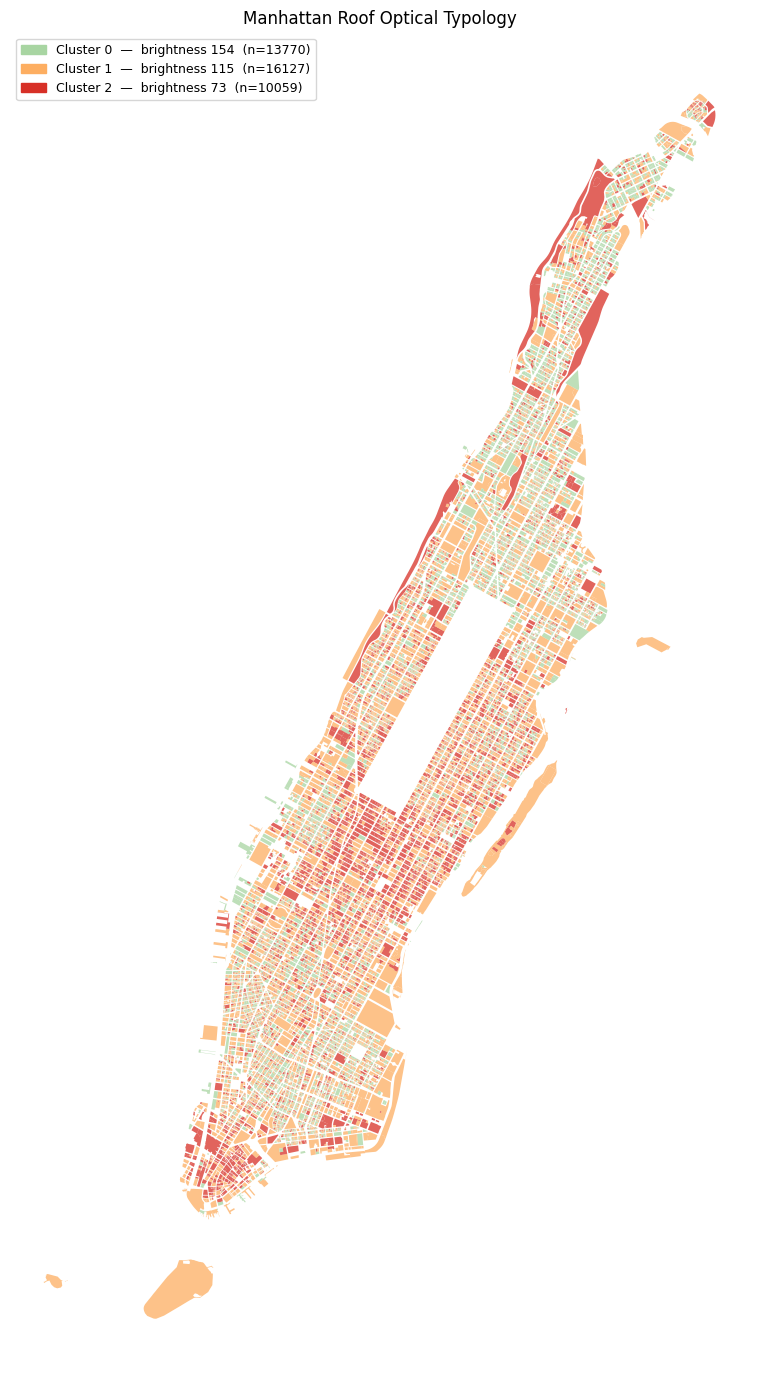

In [19]:
map_colors = {}
map_palette = ["#a8d5a2", "#fdae61", "#d73027", "#4d0000"]  # green→dark red
for i, cid in enumerate(sorted_cluster_ids):
    map_colors[cid] = map_palette[i % len(map_palette)]

pluto_v2["map_color"] = pluto_v2["optical_cluster"].map(map_colors)

fig, ax = plt.subplots(figsize=(10, 14))
pluto_v2.plot(ax=ax, color=pluto_v2["map_color"], linewidth=0, alpha=0.75)

patches = [
    mpatches.Patch(
        color=map_colors[cid],
        label=f"Cluster {cid}  —  brightness {opt_profile.loc[cid, 'brightness']:.0f}  "
              f"(n={bldg_stats.loc[cid, 'n_buildings']:.0f})"
    )
    for cid in sorted_cluster_ids
]
ax.legend(handles=patches, loc="upper left", fontsize=9)
ax.set_title(
    "Manhattan Roof Optical Typology",
    fontsize=12
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [20]:
nta = gpd.read_file(f"{DATA_DIR}/nynta2020_26a (NEIGHBORHOODS)/nynta2020.shp")
nta_mn = nta[nta["BoroName"] == "Manhattan"].copy()
nta_mn_reproj = nta_mn.to_crs(pluto_v2.crs)

pluto_nta = gpd.sjoin(
    pluto_v2[["BBL", "brightness", "optical_cluster", "geometry"]],
    nta_mn_reproj[["NTAName", "geometry"]],
    how="left",
    predicate="within"
)

nta_stats = pluto_nta.groupby("NTAName").agg(
    mean_brightness=("brightness", "mean"),
    median_brightness=("brightness", "median"),
    total_buildings=("BBL", "count"),
    dark_roof_count=("brightness", lambda x: (x < 100).sum())
).reset_index()
nta_stats["pct_dark_roofs"] = (
    nta_stats["dark_roof_count"] / nta_stats["total_buildings"] * 100
).round(1)

print("=== DARKEST NEIGHBORHOODS ===")
print(nta_stats.sort_values("mean_brightness")[
    ["NTAName", "mean_brightness", "pct_dark_roofs", "total_buildings"]
].head(15).to_string(index=False))

print("\n=== BRIGHTEST NEIGHBORHOODS ===")
print(nta_stats.sort_values("mean_brightness")[
    ["NTAName", "mean_brightness", "pct_dark_roofs", "total_buildings"]
].tail(10).to_string(index=False))

=== DARKEST NEIGHBORHOODS ===
                                    NTAName  mean_brightness  pct_dark_roofs  total_buildings
                       Midtown-Times Square        79.967873            72.1             1358
       Financial District-Battery Park City        86.343412            64.2              503
                            Highbridge Park        87.187944           100.0                1
                    East Midtown-Turtle Bay        92.463134            57.4             1025
        Midtown South-Flatiron-Union Square        99.488533            52.5             1192
             Upper West Side-Lincoln Square       103.759734            43.4              883
              Upper East Side-Carnegie Hill       105.140769            42.6             2570
                       Murray Hill-Kips Bay       107.533277            42.3             1084
                       Tribeca-Civic Center       109.719380            38.1              832
Upper East Side-Lenox Hill-Roo

## Section 8: Hybrid PCA — RGB + Building Features

- `mean_brightness` is **dropped** (not both brightness AND R, G, B)
- `bldg_area_log` replaces raw `BldgArea`

This should produce interpretable PCs where PC1 is roof color, PC2 is building scale, instead of both being collapsed into one brightness axis.

Components for 85% variance: 10
Components for 90% variance: 11


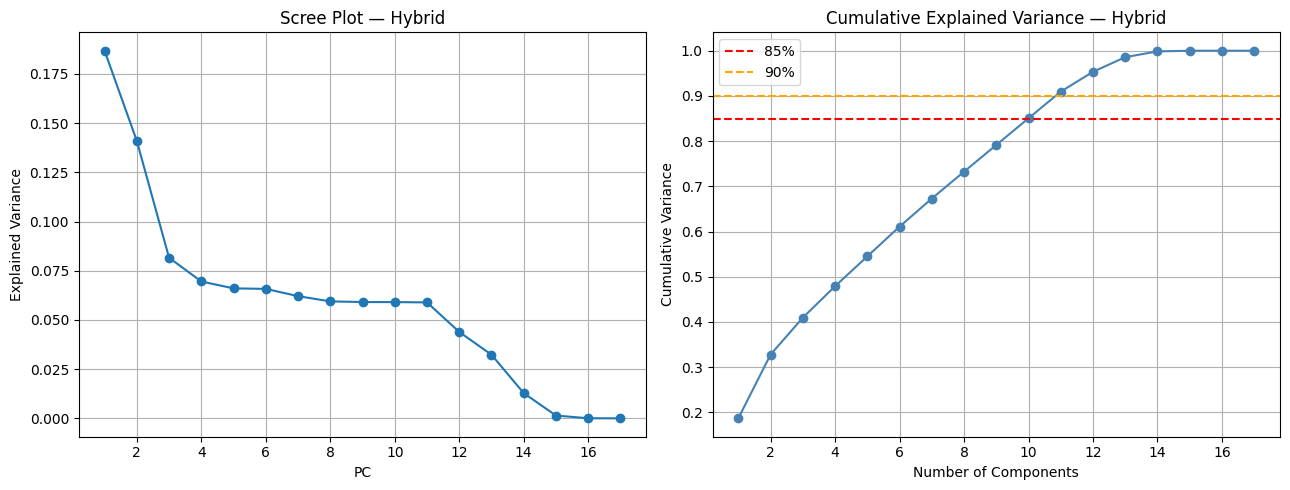


Detailed per-component breakdown:
  PC1: 0.187  (cumulative: 0.187)
  PC2: 0.141  (cumulative: 0.328)
  PC3: 0.082  (cumulative: 0.409)
  PC4: 0.070  (cumulative: 0.479)
  PC5: 0.066  (cumulative: 0.545)
  PC6: 0.066  (cumulative: 0.611)
  PC7: 0.062  (cumulative: 0.673)
  PC8: 0.059  (cumulative: 0.732)
  PC9: 0.059  (cumulative: 0.791)
  PC10: 0.059  (cumulative: 0.851)


In [21]:
hybrid_cols = ["mean_R", "mean_G", "mean_B",          # optical (no brightness)
               "YearBuilt", "bldg_area_log", "NumFloors"] + \
              [c for c in df_clean.columns if c.startswith("LU_")]

X_hybrid = df_clean[hybrid_cols].values
scaler_hyb = StandardScaler()
X_hyb_scaled = scaler_hyb.fit_transform(X_hybrid)

pca_hyb = PCA()
pca_hyb.fit(X_hyb_scaled)

cumvar_hyb = np.cumsum(pca_hyb.explained_variance_ratio_)
k_85 = int(np.searchsorted(cumvar_hyb, 0.85)) + 1
k_90 = int(np.searchsorted(cumvar_hyb, 0.90)) + 1
print(f"Components for 85% variance: {k_85}")
print(f"Components for 90% variance: {k_90}")

# Scree plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.plot(range(1, len(pca_hyb.explained_variance_ratio_)+1),
         pca_hyb.explained_variance_ratio_, marker='o')
ax1.set_xlabel("PC"); ax1.set_ylabel("Explained Variance")
ax1.set_title("Scree Plot — Hybrid")
ax1.grid(True)

ax2.plot(range(1, len(cumvar_hyb)+1), cumvar_hyb, marker='o', color='steelblue')
ax2.axhline(0.85, color='red', linestyle='--', label='85%')
ax2.axhline(0.90, color='orange', linestyle='--', label='90%')
ax2.set_xlabel("Number of Components")
ax2.set_ylabel("Cumulative Variance")
ax2.set_title("Cumulative Explained Variance — Hybrid")
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

print("\nDetailed per-component breakdown:")
for i, v in enumerate(pca_hyb.explained_variance_ratio_[:10]):
    print(f"  PC{i+1}: {v:.3f}  (cumulative: {cumvar_hyb[i]:.3f})")

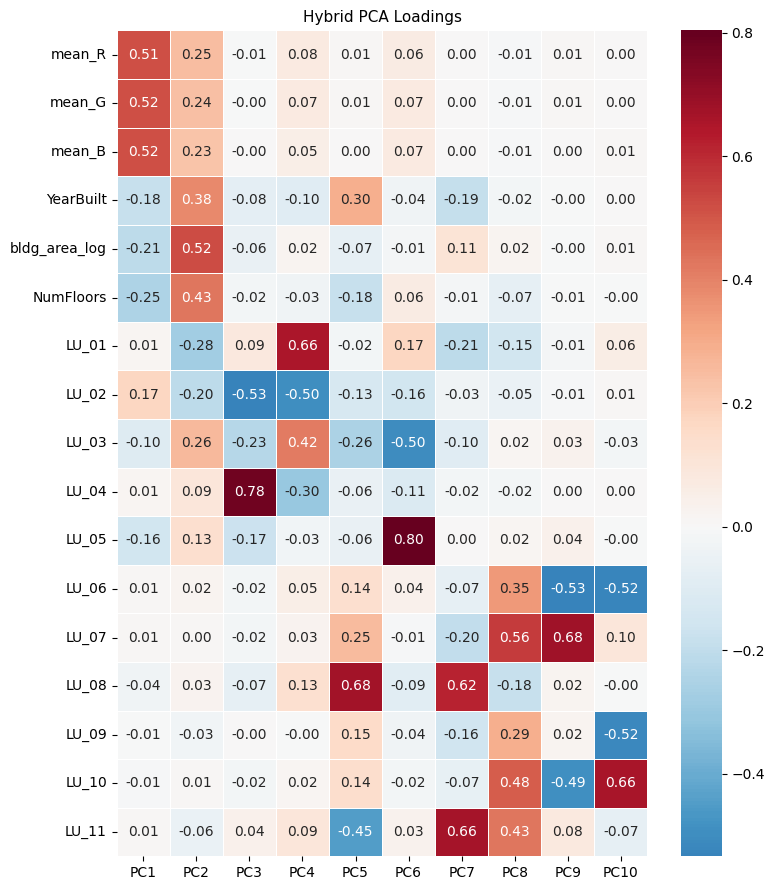

In [23]:
# Fit hybrid PCA with k_85 components
pca_hyb_k = PCA(n_components=k_85)
X_hyb_k = pca_hyb_k.fit_transform(X_hyb_scaled)

# Loadings heatmap
loadings_hyb = pd.DataFrame(
    pca_hyb_k.components_.T,
    index=hybrid_cols,
    columns=[f"PC{i+1}" for i in range(k_85)]
)

fig, ax = plt.subplots(figsize=(max(8, k_85 * 0.8), 9))
sns.heatmap(loadings_hyb, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.5, ax=ax)
ax.set_title(
    "Hybrid PCA Loadings",
    fontsize=11
)
plt.tight_layout()
plt.show()

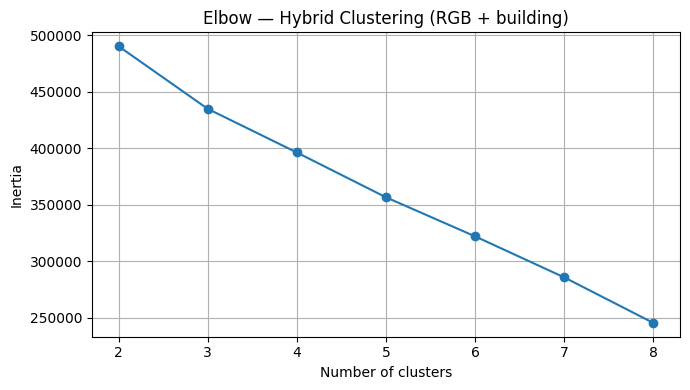

--- Hybrid Cluster Profiles (sorted brightest → darkest) ---
                mean_R  mean_G  mean_B  brightness  bldg_area_log  NumFloors  YearBuilt
hybrid_cluster                                                                         
2                147.0   145.0   146.0       146.0            9.2        4.6     1908.3
1                102.6   104.1   112.2       106.3           11.4       14.6     1952.8
0                 79.2    84.2    98.7        87.3            8.8        4.2     1904.5


In [24]:
# Elbow for hybrid clusters
inertias_hyb = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_hyb_k)
    inertias_hyb.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(range(2, 9), inertias_hyb, marker='o')
plt.xlabel("Number of clusters"); plt.ylabel("Inertia")
plt.title("Elbow — Hybrid Clustering (RGB + building)")
plt.grid(True); plt.tight_layout(); plt.show()

# Fit hybrid clusters
n_hyb = 3
km_hyb = KMeans(n_clusters=n_hyb, random_state=42, n_init=10)
df_clean["hybrid_cluster"] = km_hyb.fit_predict(X_hyb_k)

hyb_profile = df_clean.groupby("hybrid_cluster")[
    ["mean_R", "mean_G", "mean_B", "bldg_area_log", "NumFloors", "YearBuilt"]
].mean()
hyb_profile["brightness"] = (
    hyb_profile["mean_R"] + hyb_profile["mean_G"] + hyb_profile["mean_B"]
) / 3
hyb_profile = hyb_profile.sort_values("brightness", ascending=False)

print("--- Hybrid Cluster Profiles (sorted brightest → darkest) ---")
print(hyb_profile[["mean_R", "mean_G", "mean_B", "brightness", "bldg_area_log",
                    "NumFloors", "YearBuilt"]].round(1).to_string())

## Section 9: Save Results

In [25]:
# ---------------------------------------------------------------
# SAVE RESULTS — v2
#
# 1. pca_results_v2.csv (building level)
#    - BBL: unique building ID for joining to any dataset
#    - NTAName: neighborhood for joining to HVI / census data
#    - optical_cluster: roof color typology (0=brightest, n=darkest)
#    - hybrid_cluster: combined optical + building typology (if run)
#    - brightness, mean_R, mean_G, mean_B: raw color scores
#
# 2. nta_brightness_stats_v2.csv (neighborhood level)
#    - mean and median brightness per NTA
#    - % of buildings with brightness < 100 (dark roof threshold)
#    - total building count per NTA
#    Used directly by optimization component for budget allocation.
# ---------------------------------------------------------------

DATA_DIR = "/content/drive/MyDrive/Spring 2026/Applied Data Science/ADS Final Project/output"

# --- Build BBL -> NTA lookup ---
bbl_to_nta = pluto_nta[["BBL", "NTAName"]].drop_duplicates("BBL")

# --- Build output dataframe ---
# Start with optical cluster (primary result)
final_out = df_clean[["BBL", "optical_cluster"]].copy()

# Add hybrid cluster if Section 8 was run
try:
    final_out["hybrid_cluster"] = df_clean["hybrid_cluster"].values
except KeyError:
    print("Note: hybrid_cluster not found — Section 8 may not have been run. Skipping.")
    final_out["hybrid_cluster"] = None

# Add brightness and RGB scores
final_out = final_out.merge(
    brightness_df[["BBL", "brightness", "mean_R", "mean_G", "mean_B"]],
    on="BBL", how="left"
)

# Add NTA name
final_out = final_out.merge(bbl_to_nta, on="BBL", how="left")

# Add cluster label
label_map = {}
labels = ["Bright", "Medium", "Dark"] if len(sorted_cluster_ids) == 3 else \
         ["Brightest", "Bright", "Dark", "Darkest"][:len(sorted_cluster_ids)]
for rank, cid in enumerate(sorted_cluster_ids):
    label_map[cid] = labels[rank]
final_out["optical_cluster_label"] = final_out["optical_cluster"].map(label_map)

# Sanity check
print(f"Total buildings: {len(final_out)}")
print(f"Buildings with NTA assigned: {final_out['NTAName'].notna().sum()}")
print(f"Optical cluster distribution:")
print(final_out["optical_cluster_label"].value_counts())
print(f"\nBrightness range: {final_out['brightness'].min():.1f} – {final_out['brightness'].max():.1f}")
print(f"\nSample output:")
print(final_out[["BBL", "NTAName", "brightness", "optical_cluster", "optical_cluster_label"]].head(8))

# --- Save building-level results ---
out_path_v2 = f"{DATA_DIR}/pca_results_v2.csv"
final_out.to_csv(out_path_v2, index=False)
print(f"\n✓ Saved pca_results_v2.csv: {len(final_out)} buildings")

# --- Save NTA-level brightness stats ---
nta_stats_path = f"{DATA_DIR}/nta_brightness_stats_v2.csv"
nta_stats.to_csv(nta_stats_path, index=False)
print(f"✓ Saved nta_brightness_stats_v2.csv: {len(nta_stats)} neighborhoods")

# --- Quick summary for teammates ---
print("\n=== FILES SAVED FOR TEAMMATES ===")
print(f"  {out_path_v2}")
print(f"    → {len(final_out)} buildings with BBL, NTAName, brightness, cluster")
print(f"  {nta_stats_path}")
print(f"    → {len(nta_stats)} Manhattan NTAs with mean brightness + % dark roofs")
print("\nKey finding: Midtown-Times Square is the darkest neighborhood (mean brightness ~80,")
print("72% dark roofs). Harlem South is the brightest (mean ~133, 16% dark roofs).")
print("See nta_brightness_stats_v2.csv sorted by mean_brightness for full ranking.")

Total buildings: 39956
Buildings with NTA assigned: 39666
Optical cluster distribution:
optical_cluster_label
Medium    16127
Bright    13770
Dark      10059
Name: count, dtype: int64

Brightness range: 21.5 – 229.6

Sample output:
          BBL                               NTAName  brightness  \
0  1000020001                                   NaN  118.600285   
1  1000010010                                   NaN  104.561326   
2  1000050010  Financial District-Battery Park City   88.917334   
3  1000070027  Financial District-Battery Park City   32.491939   
4  1000070028  Financial District-Battery Park City   40.235884   
5  1000070029  Financial District-Battery Park City   53.447562   
6  1000070030  Financial District-Battery Park City   64.519011   
7  1000070031  Financial District-Battery Park City  108.018013   

   optical_cluster optical_cluster_label  
0                1                Medium  
1                1                Medium  
2                2                 